# Python and C++ extension

## Importing library

In [1]:
import numpy as np
import argparse
import os.path
import scipy.sparse
import vtk
from pypolydim import polydim, gedim
from pypolydim.export_vtk_utilities import ExportVTKUtilities
from pypolydim.assembler_utilities import assembler_utilities

import sys
sys.path.insert(1, '../')
import other_utilities as other_ut

### Initialize

In [2]:
geometry_utilities_config = gedim.GeometryUtilitiesConfig()
geometry_utilities_config.tolerance1_d = 1.0e-6
geometry_utilities_config.tolerance2_d = 1.0e-12
geometry_utilities = gedim.GeometryUtilities(geometry_utilities_config)
mesh_utilities = gedim.MeshUtilities()
vtk_utilities = ExportVTKUtilities()

## Test 1 - Elliptic Equation

Solving the following equation on square $\bar{\Omega} = [0, 1] \times [0, 1]$

$$
\begin{cases}
\nabla \cdot (a \nabla u) + b \cdot \nabla u + c u = f & \text{in } \Omega\\
a \nabla u \cdot n_1 = g_1 & \text{in } \Gamma_{top}\\
a \nabla u \cdot n_2 = g_2 & \text{in } \Gamma_{right}\\
u = 1.1 & \text{in } ∂Ω∖ (\Gamma_{top} ∪ \Gamma_{right})
\end{cases}
$$

where $u = 16 xy(1-x)(1-y) + 1.1$.

### Define Simulation Parameters

We define the square domain and the simulation parameters

In [3]:
# Export folder
export_file_path = "./Export/Test_1"
if not os.path.exists(export_file_path):
    os.makedirs(export_file_path)

# Mesh file path
export_mesh_path = export_file_path + "/Mesh"
if not os.path.exists(export_mesh_path):
    os.makedirs(export_mesh_path)

# Solution file path
export_solution_path = export_file_path + "/Solution"
if not os.path.exists(export_solution_path):
    os.makedirs(export_solution_path)

In [4]:
pde_domain = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D()
pde_domain.vertices = np.array([[0.0, 1.0, 1.0, 0.0],
                                [0.0, 0.0, 1.0, 1.0],
                                [0.0, 0.0, 0.0, 0.0]])
pde_domain.shape_type = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D.Domain_Shape_Types.parallelogram
pde_domain.area = 1.0

In [5]:
mesh_type = polydim.pde_tools.mesh.pde_mesh_utilities.MeshGenerator_Types_2D.triangular
method_type = polydim.pde_tools.local_space_pcc_2_d.MethodTypes.fem_pcc
method_order = 1
mesh_size = 0.01

### Create Mesh

We create the mesh using the domain definition contained in the `pde_domain` object and the `mesh_size` selected.

In [6]:
mesh_data = gedim.MeshMatrices()
mesh = gedim.MeshMatricesDAO(mesh_data)

polydim.pde_tools.mesh.pde_mesh_utilities.create_mesh_2_d(geometry_utilities,
                                                          mesh_utilities,
                                                          mesh_type,
                                                          pde_domain,
                                                          mesh_size,
                                                          mesh)
mesh_geometric_data = polydim.pde_tools.mesh.pde_mesh_utilities.compute_mesh_2_d_geometry_data(geometry_utilities, mesh_utilities, mesh)

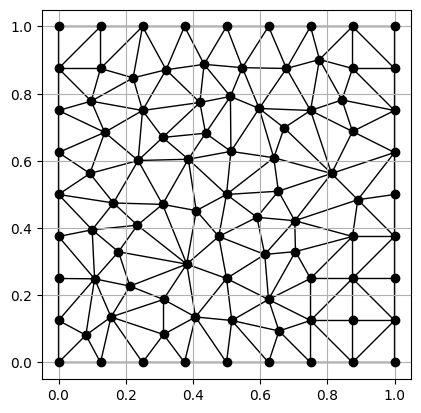

In [7]:
vtk_utilities.export_mesh(export_mesh_path, mesh)
other_ut.plot_mesh(mesh)

To description of the domain borders are passed to the library for the vertices and the edges of the domain as integer values called `markers`.
Each `marker` identifies a different boundary condition.

__In this example__:

 `marker=2` identifies $Γ_{right}$, `marker=4` identifies $Γ_{top}$ and `marker=1` identifies the Dirichlet boundary.

In [8]:
info_internal = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_internal.marker = 0

info_dirichlet = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.strong)
info_dirichlet.marker = 1

info_neumann_top = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.weak)
info_neumann_top.marker = 4

info_neumann_right = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.weak)
info_neumann_right.marker = 2

info_neumann_none = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_neumann_none.marker = 0

boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_dirichlet,
    3: info_neumann_none,
    4: info_dirichlet,
    5: info_dirichlet,
    6: info_neumann_right,
    7: info_neumann_top,
    8: info_dirichlet
}

### Create Discrete Space FEM

The boundary condition types are passed to the library during the creation of the discrete space.
The types are the following:
* `BoundaryConditionType=1`: internal mesh point;
* `BoundaryConditionType=2`: strong boundary mesh point (Dirichlet in this example);
* `BoundaryConditionType=3`: weak boundary mesh point (Neumann in this example).
The array `BoundaryConditionType` describes for each `marker` the type of boundary condition associated.

__NB__: the array has dimension `num_markers+1`, as the first element is associated to non-usable `marker=0`.

__In this example__:

we have $3$ different markers, thus `BoundaryConditionsType` has size $3+1=4$. In particular `marker=1` has type `BoundaryConditionsType[1]=2` (Dirichlet), `marker=2` has type `BoundaryConditionsType[2]=3` and `marker=3` (Neumann) has type `BoundaryConditionsType[3]=3` (Neumann).

In [9]:
mesh_connectivity_data = polydim.pde_tools.mesh.MeshMatricesDAO_mesh_connectivity_data(mesh)

trial_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, method_order)
test_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, method_order)

dof_manager = polydim.pde_tools.do_fs.DOFsManager()

trial_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(trial_reference_element_data, mesh, boundary_info)
trial_dofs_data = dof_manager.create_do_fs_2_d(trial_mesh_dofs_info, mesh_connectivity_data)
test_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(trial_reference_element_data, mesh, boundary_info)
test_dofs_data = dof_manager.create_do_fs_2_d(test_mesh_dofs_info, mesh_connectivity_data)

### Assemble linear system

In [10]:
a = 10.0
b = np.array([0.1, 0.1, 0.1])
c = 2.0

def exact_solution_function(x, y, z):
    return 16.0 * x * y * (1.0 - x) * (1.0 - y) + 1.1

def exact_gradient_solution_function(x, y, z):
    return np.array([\
        16.0 * (1.0 - 2.0 * x) * y * (1.0 - y),\
        16.0 * (1.0 - 2.0 * y) * x * (1.0 - x),\
        0.0])

def exact_laplacian_solution_function(x, y, z):
    return -32.0 * (x * (1.0 - x) + y * (1.0 - y))

In [11]:
def source_term_function(x, y, z):
    u_lap = exact_laplacian_solution_function(x, y, z)
    u_grad = exact_gradient_solution_function(x, y, z)
    u = exact_solution_function(x, y, z)

    return -a * u_lap + (b[0] * u_grad[0] + b[1] * u_grad[1] + b[2] * u_grad[2]) + c * u;

source_term = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       test_dofs_data,
                                                                       trial_reference_element_data,
                                                                       test_reference_element_data,
                                                                       source_term_function)
                                                                       

In [12]:
def strong_solution_function(marker, x, y, z):  
    return exact_solution_function(x, y, z)

u_D = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       trial_mesh_dofs_info,
                                                                       trial_dofs_data,
                                                                       trial_reference_element_data,
                                                                       strong_solution_function)

In [13]:
def weak_term_function(marker, x, y, z):
    u_grad = exact_gradient_solution_function(x, y, z)
    match marker:
        case 2:
            return a * u_grad[0] 
        case 4:
            return a * u_grad[1] 
        case _:
            raise ValueError("not valid marker")


weak_term = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_weak_term(geometry_utilities,
                                                                             mesh,
                                                                             mesh_geometric_data,
                                                                             trial_mesh_dofs_info,
                                                                             test_dofs_data,
                                                                             trial_reference_element_data,
                                                                             test_reference_element_data,
                                                                             weak_term_function)

In [14]:
def diffusion_term_function(x, y, z):  
    return a
def advection_term_function(x, y, z):  
    return b
def reaction_term_function(x, y, z):  
    return c

diffusion = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       trial_dofs_data,
                                                                                             test_dofs_data,
                                                                       trial_reference_element_data,
                                                                                             test_reference_element_data,
                                                                       diffusion_term_function)


A1 = other_ut.make_np_sparse(diffusion.operator_dofs)
A1_D = other_ut.make_np_sparse(diffusion.operator_strong)

advection = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       trial_dofs_data,
                                                                                             test_dofs_data,
                                                                       trial_reference_element_data,
                                                                                             test_reference_element_data,
                                                                       advection_term_function)


A2 = other_ut.make_np_sparse(advection.operator_dofs)
A2_D = other_ut.make_np_sparse(advection.operator_strong)

reaction = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_reaction_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       trial_dofs_data,
                                                                                             test_dofs_data,
                                                                       trial_reference_element_data,
                                                                                             test_reference_element_data,
                                                                       reaction_term_function)


A3 = other_ut.make_np_sparse(reaction.operator_dofs)
A3_D = other_ut.make_np_sparse(reaction.operator_strong)

A = A1 + A2 + A3
A_D = A1_D + A2_D + A3_D

### Solve linear system

In [15]:
rhs = source_term + weak_term - A_D @ u_D
u = scipy.sparse.linalg.spsolve(A, rhs)

### Compute errors

In [16]:
u_ext = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_exact_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                             trial_dofs_data,
                                                                       trial_reference_element_data,
                                                                       exact_solution_function)

In [17]:
u_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       trial_dofs_data,
                                                                                         u,
                                                                                         u_D,
                                                                       exact_solution_function)

In [18]:
error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       trial_dofs_data,
                                                                       trial_reference_element_data,
                                                                          u,
                                                                          u_D,
                                                                       exact_solution_function)

error_H1 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_h1(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       trial_dofs_data,
                                                                       trial_reference_element_data,
                                                                          u,
                                                                          u_D,
                                                                       exact_gradient_solution_function)


print("dofs", "errorL2", "errorH1")
print(trial_dofs_data.number_do_fs, '{:.2e}'.format(error_L2.error_l2 / error_L2.numeric_norm_l2), '{:.2e}'.format(error_H1.error_h1 / error_H1.numeric_norm_h1))

dofs errorL2 errorH1
72 7.84e-03 1.79e-01


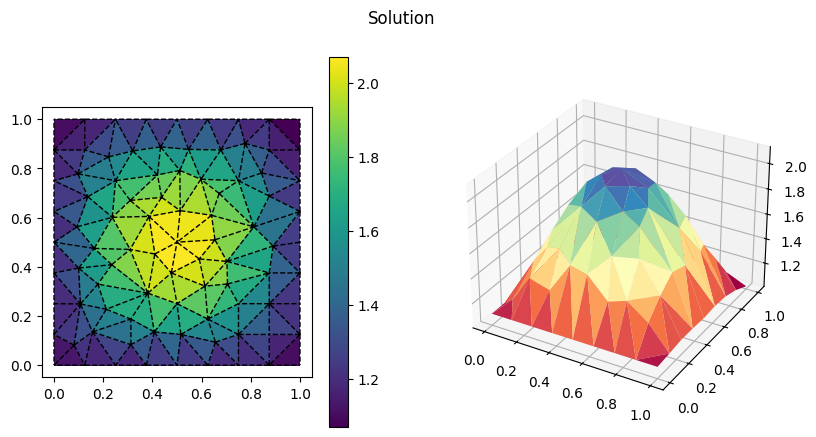

In [19]:
vtk_utilities.export_solution_2(export_solution_path + '/Solution.vtu',
                                mesh, 
                                u_on_cell0Ds.numeric_solution,
                                u_on_cell0Ds.exact_solution,
                                error_L2.cell2_ds_error_l2,
                               error_H1.cell2_ds_error_h1)
other_ut.plot_solution(mesh, u_on_cell0Ds.numeric_solution) 

## Test 2 -  Heat Conductivity Equation

Solving the following equation on square $\bar{\Omega} = [-1, +1] \times [-1, +1]$

$$
\begin{cases}
\nabla \cdot (k \nabla u) = 0 & \text{in } \Omega\\
k \nabla u \cdot n_1 = g & \text{in } \Gamma_{down}\\
u = 0 & \text{in } \Gamma_{up}\\
k \nabla u \cdot n_2 = 0 & \text{otherwise} 
\end{cases}
$$

where $k = k_1$ if $x^2 + y^2 \leq R^2$ and $k = 1$ otherwise. 

### Set simulation parameters

In [20]:
# Export folder
export_file_path = "./Export/Test_2"
if not os.path.exists(export_file_path):
    os.makedirs(export_file_path)

# Mesh file path
export_mesh_path = export_file_path + "/Mesh"
if not os.path.exists(export_mesh_path):
    os.makedirs(export_mesh_path)

# Solution file path
export_solution_path = export_file_path + "/Solution"
if not os.path.exists(export_solution_path):
    os.makedirs(export_solution_path)

In [21]:
mesh_type = polydim.pde_tools.mesh.pde_mesh_utilities.MeshGenerator_Types_2D.csv_importer
method_type = polydim.pde_tools.local_space_pcc_2_d.MethodTypes.fem_pcc
import_mesh_folder = "./Test_Mesh" # Mesh2
method_order = 2

### Import Mesh

In [22]:
mesh_data = gedim.MeshMatrices()
mesh = gedim.MeshMatricesDAO(mesh_data)

polydim.pde_tools.mesh.pde_mesh_utilities.import_mesh_2_d(mesh_utilities,
                                                          mesh_type,
                                                          import_mesh_folder,
                                                          mesh)
mesh_geometric_data = polydim.pde_tools.mesh.pde_mesh_utilities.compute_mesh_2_d_geometry_data(geometry_utilities, mesh_utilities, mesh)

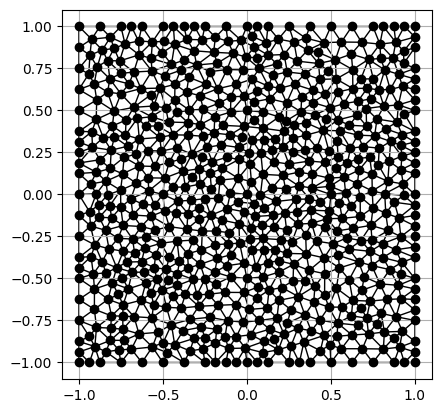

In [23]:
vtk_utilities.export_mesh(export_mesh_path, mesh)
other_ut.plot_mesh(mesh)

### Create Discrete Space FEM

In [ ]:
info_internal = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_internal.marker = 0

info_dirichlet_up = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.strong)
info_dirichlet_up.marker = 3

info_neumann_down = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.weak)
info_neumann_down.marker = 1

info_neumann_none = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_neumann_none.marker = 2

boundary_info = {
    0: info_internal,
    1: info_neumann_down,
    2: info_neumann_none,
    3: info_dirichlet_up
}

In [ ]:
mesh_connectivity_data = polydim.pde_tools.mesh.MeshMatricesDAO_mesh_connectivity_data(mesh)

trial_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, method_order)
test_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, method_order)

dof_manager = polydim.pde_tools.do_fs.DOFsManager()

trial_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(trial_reference_element_data, mesh, boundary_info)
trial_dofs_data = dof_manager.create_do_fs_2_d(trial_mesh_dofs_info, mesh_connectivity_data)
test_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(trial_reference_element_data, mesh, boundary_info)
test_dofs_data = dof_manager.create_do_fs_2_d(test_mesh_dofs_info, mesh_connectivity_data)

### Assemble linear system

In [ ]:
R = 0.5
k = 6.68
g = 0.94

def diffusion_term_function(x, y, z):
    if (x * x + y * y) <= (R * R + 1.0e-13):
        return k
    return 1.0

diffusion = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(geometry_utilities,
                                                                                      mesh,
                                                                                      mesh_geometric_data,
                                                                                      trial_dofs_data,
                                                                                      test_dofs_data,
                                                                                      trial_reference_element_data,
                                                                                      test_reference_element_data,
                                                                                      diffusion_term_function)


A = other_ut.make_np_sparse(diffusion.operator_dofs)
A_D = other_ut.make_np_sparse(diffusion.operator_strong)

def weak_term_function(marker, x, y, z):
    match marker:
        case 1:
            return g
        case _:
            raise ValueError("not valid marker", marker)


weak_term = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_weak_term(geometry_utilities,
                                                                             mesh,
                                                                             mesh_geometric_data,
                                                                             trial_mesh_dofs_info,
                                                                             test_dofs_data,
                                                                             trial_reference_element_data,
                                                                             test_reference_element_data,
                                                                             weak_term_function)

def strong_solution_function(marker, x, y, z):  
    return 0.0

u_D = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       trial_mesh_dofs_info,
                                                                       trial_dofs_data,
                                                                       trial_reference_element_data,
                                                                       strong_solution_function)

### Solve linear system

In [ ]:
rhs = weak_term - A_D @ u_D
u = scipy.sparse.linalg.spsolve(A, rhs)

In [ ]:
u_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       trial_dofs_data,
                                                                                         u,
                                                                                         u_D)

In [ ]:
vtk_utilities.export_solution_2(export_solution_path + '/Solution.vtu',
                                mesh, 
                                u_on_cell0Ds.numeric_solution)
other_ut.plot_solution(mesh, u_on_cell0Ds.numeric_solution) 